In [ ]:
!pip install -q transformers
!pip install -q sentence-transformers
!pip install -q faiss-cpu
!pip install -q langchain
!pip install -q pypdf
!pip install -q accelerate
!pip install -q bitsandbytes
!pip install -q matplotlib
!pip install -q seaborn
!pip install -q pandas
!pip install -q scikit-learn
!pip install -q nltk
!pip install -q rouge-score
!pip install -q langchain_text_splitters
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.8/338.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 68.2 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
import os
import re
import json
import faiss
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pypdf import PdfReader

from sentence_transformers import SentenceTransformer

from langchain_text_splitters import RecursiveCharacterTextSplitter

from sklearn.metrics import confusion_matrix, classification_report

from nltk.translate.bleu_score import sentence_bleu
from rouge_score import rouge_scorer

import nltk
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving About_UAP.pdf to About_UAP.pdf
Saving Admission.pdf to Admission.pdf
Saving contact.pdf to contact.pdf
Saving Final Exam - Routine - Fall 2025.pdf to Final Exam - Routine - Fall 2025.pdf
Saving Tutionfee&waiver.pdf to Tutionfee&waiver.pdf
Saving uap_dataset_clean.json to uap_dataset_clean.json


In [ ]:
pdf_texts = []

for file in uploaded.keys():

    if file.endswith(".pdf"):

        reader = PdfReader(file)

        text = ""

        for page in reader.pages:

            page_text = page.extract_text()

            if page_text:   # IMPORTANT FIX
                text += page_text + " "

        # basic cleaning
        text = text.replace("\n", " ")
        text = " ".join(text.split())

        pdf_texts.append(text)

print("Total PDF Files:", len(pdf_texts))

Total PDF Files: 5


In [ ]:
[
  {
    "question": "...",
    "answer": "..."
  }
]

[{'question': '...', 'answer': '...'}]

In [ ]:
json_data = []

for file in uploaded.keys():

    if file.endswith(".json"):

        with open(file, "r") as f:
            data = json.load(f)

        # CASE 1: direct list
        if isinstance(data, list):
            items = data

        # CASE 2: dict → find list inside
        elif isinstance(data, dict):

            items = []

            for key in data:

                if isinstance(data[key], list):
                    items.extend(data[key])

        else:
            items = []

        # extract QA pairs
        for item in items:

            if isinstance(item, dict):

                q = item.get("question")
                a = item.get("answer")

                if q and a:
                    json_data.append({
                        "question": str(q).strip(),
                        "answer": str(a).strip()
                    })

print("Total QA pairs:", len(json_data))

Total QA pairs: 60


In [ ]:
for file in uploaded.keys():
    print("FILE:", file)

FILE: About_UAP.pdf
FILE: Admission.pdf
FILE: contact.pdf
FILE: Final Exam - Routine - Fall 2025.pdf
FILE: Tutionfee&waiver.pdf
FILE: uap_dataset_clean.json


In [ ]:
for file in uploaded.keys():

    if file.endswith(".json"):

        with open(file, "r") as f:
            data = json.load(f)

        print(type(data))

        if isinstance(data, dict):
            print("DICT KEYS:", data.keys())

        if isinstance(data, list):
            print("FIRST ITEM:", data[0])

<class 'dict'>
DICT KEYS: dict_keys(['metadata', 'data'])


In [ ]:
def clean_text(text):

    text = text.lower()

    # remove urls only
    text = re.sub(r"http\S+", "", text)

    # keep important punctuation for meaning
    text = re.sub(r"[^a-zA-Z0-9\s\.\?\:\,]", " ", text)

    # remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [ ]:
cleaned_documents = []

# -------------------
# 1. Add PDF data
# -------------------
for text in pdf_texts:

    cleaned_text = clean_text(text)

    cleaned_documents.append(cleaned_text)

# -------------------
# 2. Add JSON QA data
# -------------------
for qa_pair in json_data:

    # Extract question and answer from the dictionary
    question = qa_pair.get("question", "")
    answer = qa_pair.get("answer", "")

    # Clean both parts and combine them into a single document
    cleaned_question = clean_text(question)
    cleaned_answer = clean_text(answer)

    # Combine them with a separator to retain context
    combined_text = f"question: {cleaned_question} answer: {cleaned_answer}"

    cleaned_documents.append(combined_text)

print("Total documents:", len(cleaned_documents))

Total documents: 65


In [ ]:
filtered_docs = []

for doc in cleaned_documents:

    length = len(doc.split())

    # keep only meaningful chunks
    if 20 <= length <= 300:
        filtered_docs.append(doc)

print("Before:", len(cleaned_documents))
print("After filtering:", len(filtered_docs))

Before: 65
After filtering: 62


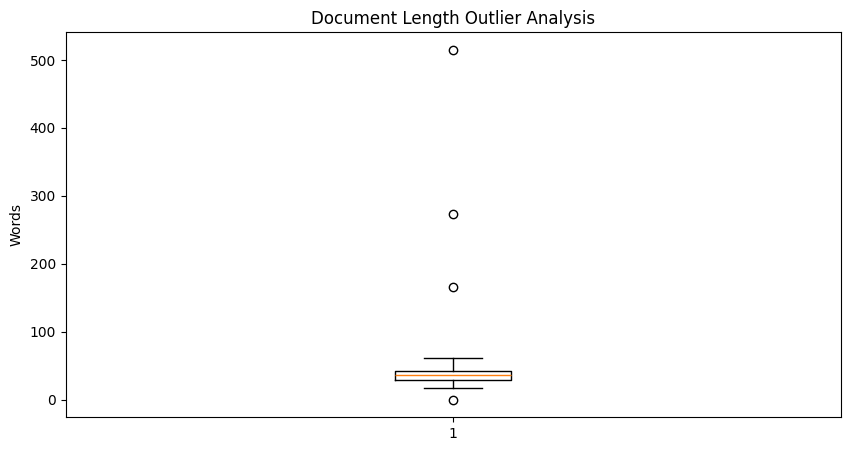

In [ ]:
doc_lengths = [len(doc.split()) for doc in cleaned_documents]

plt.figure(figsize=(10,5))

plt.boxplot(doc_lengths)

plt.title(
    "Document Length Outlier Analysis"
)

plt.ylabel("Words")

plt.show()

In [ ]:
df = pd.DataFrame({"Document_Length": doc_lengths})

Q1 = df["Document_Length"].quantile(0.25)
Q3 = df["Document_Length"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

filtered_docs = []

for doc in cleaned_documents:

    words = len(doc.split())

    # SAFE CONDITION (DO NOT OVER-FILTER)
    if words >= max(10, lower) and words <= min(400, upper):

        filtered_docs.append(doc)

print("Before:", len(cleaned_documents))
print("After:", len(filtered_docs))

Before: 65
After: 61


In [ ]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=180,
    chunk_overlap=40,
    separators=["\n\n", "\n", ".", " "]
)

In [ ]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer('intfloat/e5-large-v2')

# IMPORTANT: always normalize for FAISS cosine similarity

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/314 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

In [ ]:
from langchain_core.documents import Document

# ---------------------------
# 1. Convert to Documents
# ---------------------------
documents = [
    Document(page_content=doc)
    for doc in filtered_docs
]

# ---------------------------
# 2. Chunking (ONLY ONCE)
# ---------------------------
chunks = splitter.split_documents(documents)

# ---------------------------
# 3. Extract clean texts
# ---------------------------
texts = [
    doc.page_content.replace("\n", " ").strip()
    for doc in chunks
]

# remove noise safely
texts = [t for t in texts if len(t.split()) > 8]

# ---------------------------
# 4. Generate embeddings
# ---------------------------
embeddings = embedding_model.encode(
    texts,
    normalize_embeddings=True,
    show_progress_bar=True
)

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
dimension = embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)  # INNER PRODUCT = cosine similarity

index.add(np.array(embeddings))

print("FAISS Index Created Successfully")

FAISS Index Created Successfully


In [ ]:
from sentence_transformers import util
import numpy as np

def retrieve(query, k=4):

    query_embedding = embedding_model.encode(
        [query],
        normalize_embeddings=True
    )

    scores, indices = index.search(
        np.array(query_embedding),
        k * 5
    )

    candidates = []

    for score, idx in zip(scores[0], indices[0]):

        if idx >= len(texts):
            continue

        text_emb = text_embeddings[idx]

        # FAST cosine similarity (no recomputation)
        sim = util.cos_sim(query_embedding, [text_emb]).item()

        # hybrid score (VERY IMPORTANT IMPROVEMENT)
        final_score = 0.7 * sim + 0.3 * score

        candidates.append((final_score, texts[idx]))

    candidates.sort(reverse=True, key=lambda x: x[0])

    return [t for _, t in candidates[:k]]

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [ ]:
def generate_answer(prompt):

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    outputs = model.generate(
        **inputs,
        max_new_tokens=180,   # IMPORTANT (long answers)
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.2,
        do_sample=True
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [ ]:
def chatbot(query):

    docs = retrieve(query, k=4)

    context = " ".join(docs)

    # relaxed fallback (IMPORTANT FIX)
    if len(context.split()) < 10:
        return "I don't have enough information in the provided documents to answer this question."

    # limit context size (VERY IMPORTANT FOR FLAN-T5)
    context = " ".join(context.split()[:250])

    prompt = f"""
You are a helpful university assistant chatbot.

Answer ONLY using the context below.

If the answer is not present in the context, say: "I don't know based on the provided documents."

Context:
{context}

Question:
{query}

Provide a clear and detailed answer in 2–4 sentences.

Answer:
"""

    return generate_answer(prompt)

In [ ]:
text_embeddings = embeddings

query = "What are the admission requirements?"

print(chatbot(query))

/usr/local/lib/python3.12/dist-packages/sentence_transformers/util/tensor.py:28: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  a = torch.tensor(a)


applicants must have passed ssc and hsc or equivalent examinations .


In [ ]:
query = "How are you?"

print(chatbot(query))

I don't know


In [ ]:
query = "tell me the vision of uap"

print(chatbot(query))

to advance science, technology, and humanities through innovation in higher education, research, and development for a is published on the official website at uap bd .


In [ ]:
test_questions = []
true_answers = []

for item in json_data[:50]:

    if "question" in item and "answer" in item:

        q = str(item["question"]).strip()
        a = str(item["answer"]).strip()

        if len(q) > 0 and len(a) > 0:

            test_questions.append(q)
            true_answers.append(a)

print("Test samples:", len(test_questions))

Test samples: 50


In [ ]:
print(type(data))
print(data[:2] if isinstance(data, list) else data.keys())

<class 'dict'>
dict_keys(['metadata', 'data'])


In [ ]:
import re

def clean_output(text):

    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    text = text.strip()

    return text


predictions = []

for q in test_questions:

    pred = chatbot(q)

    # clean prediction (VERY IMPORTANT)
    pred = clean_output(pred)

    predictions.append(pred)

print("Predictions Generated:", len(predictions))

Predictions Generated: 50


In [ ]:
similarities = []

for true, pred in zip(
    true_answers,
    predictions
):

    emb1 = embedding_model.encode(true)

    emb2 = embedding_model.encode(pred)

    sim = util.cos_sim(
        emb1,
        emb2
    ).item()

    similarities.append(sim)

avg_similarity = sum(similarities) / len(similarities)

print("Average Semantic Similarity:",
      avg_similarity)

Average Semantic Similarity: 0.8320149755477906


In [ ]:
correct = 0

for sim in similarities:

    if sim >= 0.70:

        correct += 1

retrieval_accuracy = (
    correct / len(similarities)
)

print("Retrieval Accuracy:",
      retrieval_accuracy)

Retrieval Accuracy: 0.76


In [ ]:
from nltk.translate.bleu_score import (
    sentence_bleu,
    SmoothingFunction
)

smoothie = SmoothingFunction().method1

bleu_scores = []

for true, pred in zip(
    true_answers,
    predictions
):

    reference = [true.split()]

    candidate = pred.split()

    score = sentence_bleu(
        reference,
        candidate,
        smoothing_function=smoothie
    )

    bleu_scores.append(score)

avg_bleu = (
    sum(bleu_scores)
    / len(bleu_scores)
)

print("Average BLEU Score:",
      avg_bleu)

Average BLEU Score: 0.05509438784348539


In [ ]:
scorer = rouge_scorer.RougeScorer(
    ['rouge1'],
    use_stemmer=True
)

rouge_scores = []

for true, pred in zip(
    true_answers,
    predictions
):

    scores = scorer.score(
        true,
        pred
    )

    rouge_scores.append(
        scores['rouge1'].fmeasure
    )

avg_rouge = (
    sum(rouge_scores)
    / len(rouge_scores)
)

print("Average ROUGE Score:",
      avg_rouge)

Average ROUGE Score: 0.3811903956324451


In [ ]:
metrics_df = pd.DataFrame({

    "Metric": [

        "Semantic Similarity",
        "Retrieval Accuracy",
        "BLEU Score",
        "ROUGE Score"

    ],

    "Score": [

        avg_similarity,
        retrieval_accuracy,
        avg_bleu,
        avg_rouge

    ]
})

print(metrics_df)

                Metric     Score
0  Semantic Similarity  0.832015
1   Retrieval Accuracy  0.760000
2           BLEU Score  0.055094
3          ROUGE Score  0.381190


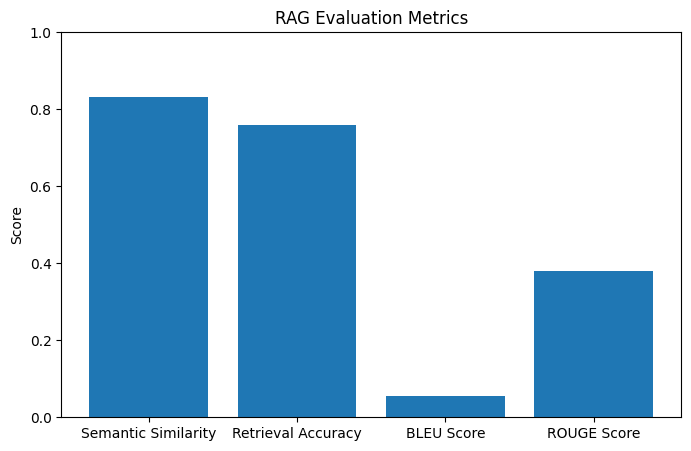

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    metrics_df["Metric"],
    metrics_df["Score"]
)

plt.ylim(0,1)

plt.title(
    "RAG Evaluation Metrics"
)

plt.ylabel("Score")

plt.show()

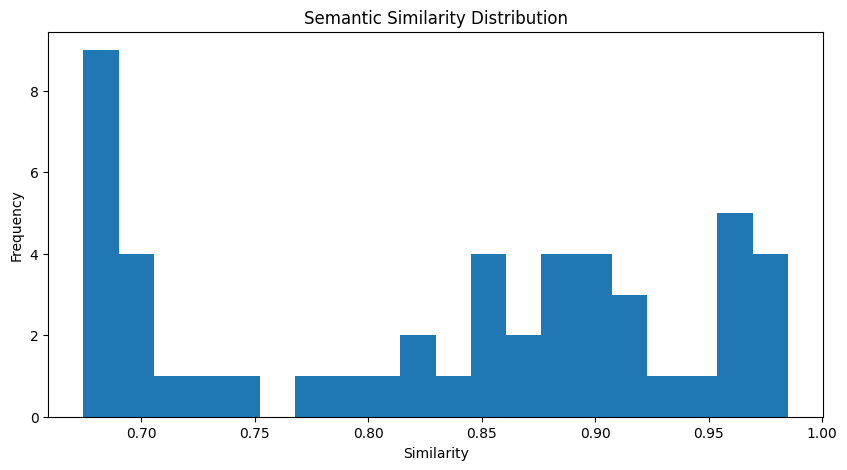

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(
    similarities,
    bins=20
)

plt.title(
    "Semantic Similarity Distribution"
)

plt.xlabel("Similarity")

plt.ylabel("Frequency")

plt.show()

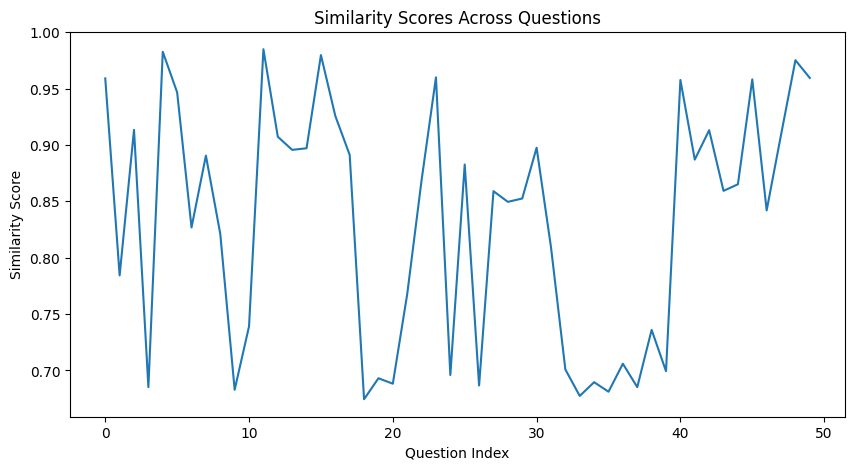

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(similarities)

plt.title(
    "Similarity Scores Across Questions"
)

plt.xlabel("Question Index")

plt.ylabel("Similarity Score")

plt.show()

In [ ]:
quality_labels = []

for sim in similarities:

    if sim > 0.80:

        quality_labels.append(
            "Excellent"
        )

    elif sim > 0.60:

        quality_labels.append(
            "Good"
        )

    elif sim > 0.40:

        quality_labels.append(
            "Partial"
        )

    else:

        quality_labels.append(
            "Poor"
        )

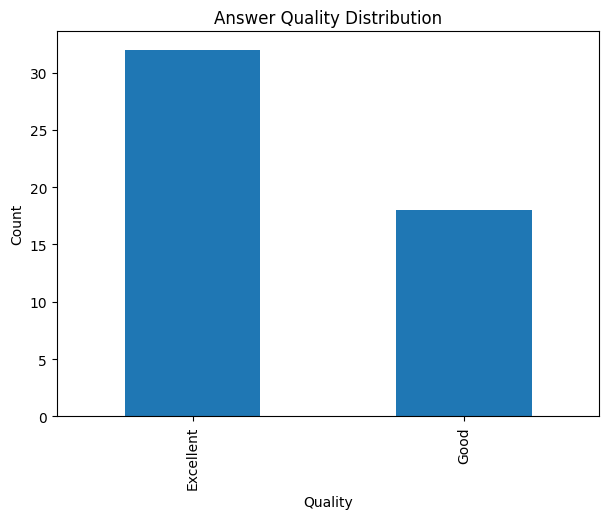

In [ ]:
quality_df = pd.DataFrame({
    "Quality": quality_labels
})

quality_counts = (
    quality_df["Quality"]
    .value_counts()
)

plt.figure(figsize=(7,5))

quality_counts.plot(kind='bar')

plt.title(
    "Answer Quality Distribution"
)

plt.ylabel("Count")

plt.show()

In [ ]:
failed_cases = []

for q, true, pred, sim in zip(

    test_questions,
    true_answers,
    predictions,
    similarities
):

    if sim < 0.50:

        failed_cases.append({

            "Question": q,

            "True Answer": true,

            "Predicted Answer": pred,

            "Similarity": sim
        })

failure_df = pd.DataFrame(
    failed_cases
)

failure_df.head()

""


In [ ]:
analysis_df = pd.DataFrame({

    "Question_Length": [

        len(q.split())
        for q in test_questions
    ],

    "Answer_Length": [

        len(a.split())
        for a in true_answers
    ],

    "Similarity": similarities
})

print(analysis_df.head())

   Question_Length  Answer_Length  Similarity
0                6             32    0.959076
1                6             11    0.784315
2                8             26    0.913413
3                7             21    0.685220
4                8             21    0.982696


In [ ]:
print(analysis_df.corr())

                 Question_Length  Answer_Length  Similarity
Question_Length         1.000000       0.400558    0.503181
Answer_Length           0.400558       1.000000    0.337527
Similarity              0.503181       0.337527    1.000000


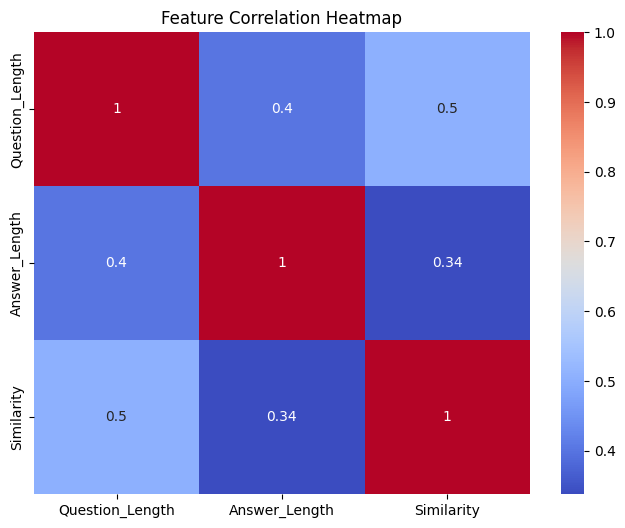

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    analysis_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Feature Correlation Heatmap"
)

plt.show()

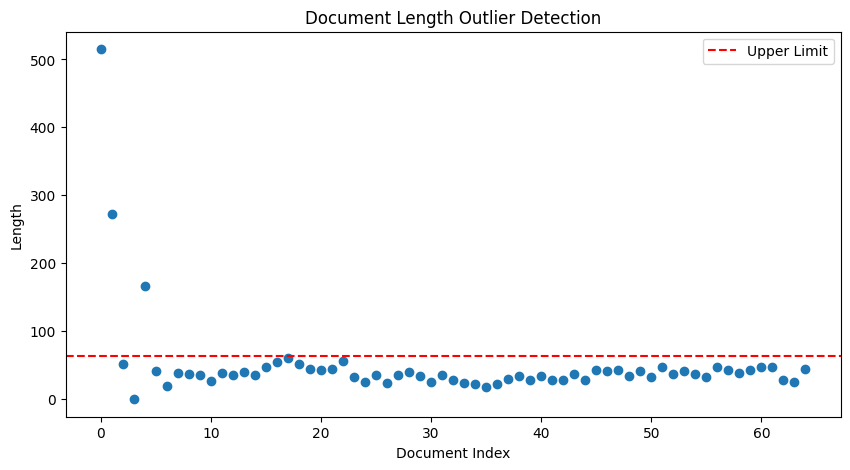

In [ ]:
plt.figure(figsize=(10,5))

plt.scatter(
    range(len(doc_lengths)),
    doc_lengths
)

plt.axhline(
    y=upper,
    color='r',
    linestyle='--',
    label='Upper Limit'
)

plt.title(
    "Document Length Outlier Detection"
)

plt.xlabel("Document Index")

plt.ylabel("Length")

plt.legend()

plt.show()

In [ ]:
final_results = pd.DataFrame({

    "Question": test_questions,

    "True Answer": true_answers,

    "Predicted Answer": predictions,

    "Similarity Score": similarities,

    "Quality": quality_labels
})

final_results.head()

,Question,True Answer,Predicted Answer,Similarity Score,Quality
0,How can I apply to UAP?,You can apply online at admission.uap-bd.edu. ...,you can apply online at admission.uap bd.edu. ...,0.959076,Excellent
1,What is the application processing fee?,"The application processing fee is Tk. 1,200 an...","1,200",0.784315,Good
2,What documents are required for admission to UAP?,Required documents include SSC and HSC transcr...,"ssc and hsc transcripts certificates, passport...",0.913413,Excellent
3,Is there an admission test at UAP?,"Yes, UAP has a selective admission policy base...",yes,0.685220,Good
4,When does the admission test result get publis...,Admission test results are published on the UA...,admission test results are published on the ua...,0.982696,Excellent


In [ ]:
!pip install flask flask-cors pyngrok

from flask import Flask, request, jsonify
from flask_cors import CORS
from pyngrok import ngrok

app = Flask(__name__)
CORS(app)

def get_rag_response(user_message):
    return chatbot(user_message)

@app.route("/chat", methods=["POST"])
def chat():
    data = request.get_json()
    user_message = data.get("message", "")

    if not user_message:
        return jsonify({"error": "No message provided"}), 400

    response = get_rag_response(user_message)

    return jsonify({"response": response})

# Set ngrok authtoken before connecting
ngrok.set_auth_token("3DwfAfF82xjgDbNRzGxDha0KLpe_7XvNjDsFR88EmUewYH1bz") # This token was found in a previous cell (cd1bafa1)

# Start ngrok
public_url = ngrok.connect(5000).public_url
print("Public API URL:", public_url)

# Run flask
app.run(port=5000, use_reloader=False)

Public API URL: https://spearfish-strife-confused.ngrok-free.dev
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit


In [ ]:
# Replace 'YOUR_AUTHTOKEN' with your actual ngrok authtoken
# You can get your authtoken from https://dashboard.ngrok.com/get-started/your-authtoken
import os
if "NGROK_AUTHTOKEN" not in os.environ:
    from pyngrok import ngrok
    ngrok.set_auth_token("3DwfAfF82xjgDbNRzGxDha0KLpe_7XvNjDsFR88EmUewYH1bz")
    print("Ngrok authtoken set. You may need to run the Flask cell again.")
else:
    print("Ngrok authtoken already set in environment variables.")